In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
# tab_gid = "512741424"
tab_gid = "1990888583" 
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU"])
df

,Model,Compression,BLEU
0,pythia-70M,Original,42.00
1,pythia-70M,8-bit,41.39
2,pythia-70M,4-bit,39.21
3,pythia-160M,Original,42.49
4,pythia-160M,8-bit,42.31
5,pythia-160M,4-bit,40.60
6,pythia-410M,Original,43.51
7,pythia-410M,8-bit,43.61
8,pythia-410M,4-bit,42.41
9,pythia-1B,Original,44.18


# RQ-4: Generalizibility check

## RQ-1: precision vs task performance

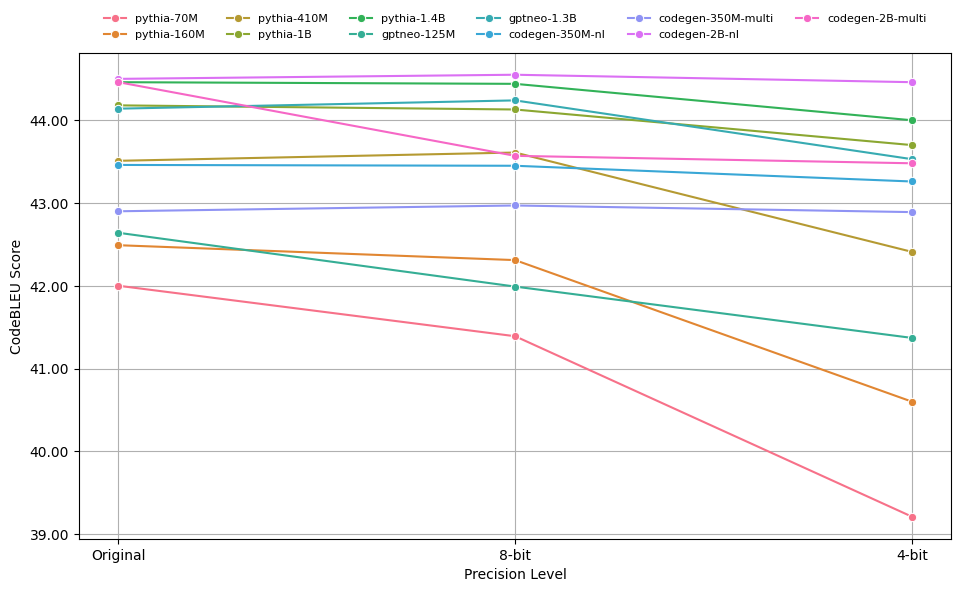

In [13]:
compression_order = ["Original", "8-bit", "4-bit"]
df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Compression", y="BLEU", hue="Model", marker="o")

# plt.title("BLEU Score Across Compression Levels for Different Pythia Models")
plt.ylabel("CodeBLEU Score")
plt.xlabel("Precision Level")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))

# plt.ylim(0.38, 0.46)
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=6, fontsize=8, frameon=False)

# plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("./output/RQ-4.1.1.png", dpi=300, bbox_inches="tight")
plt.show()

## RQ-2: precision vs MIA

In [19]:
def graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-4.2.1.png"):
    compression_order = ["Original", "8-bit", "4-bit"]
    df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="Compression", y=score_col, hue="Model", marker="o")
    # plt.title(f"{miaName}({score_col}) Score Across Compression Levels for Different Pythia Models")
    plt.ylabel(f"{score_col} Score")
    plt.xlabel("Precision Level")
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
    plt.grid(True)
    # plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=6, fontsize=8, frameon=False)
    plt.tight_layout()
    plt.savefig(f"./output/{fileName}", dpi=300, bbox_inches="tight")
    plt.show()

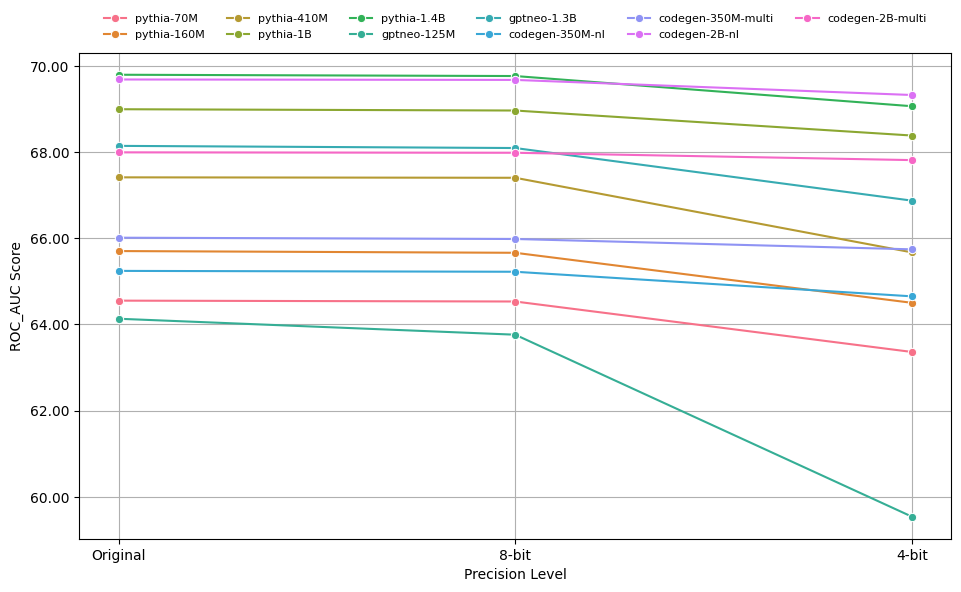

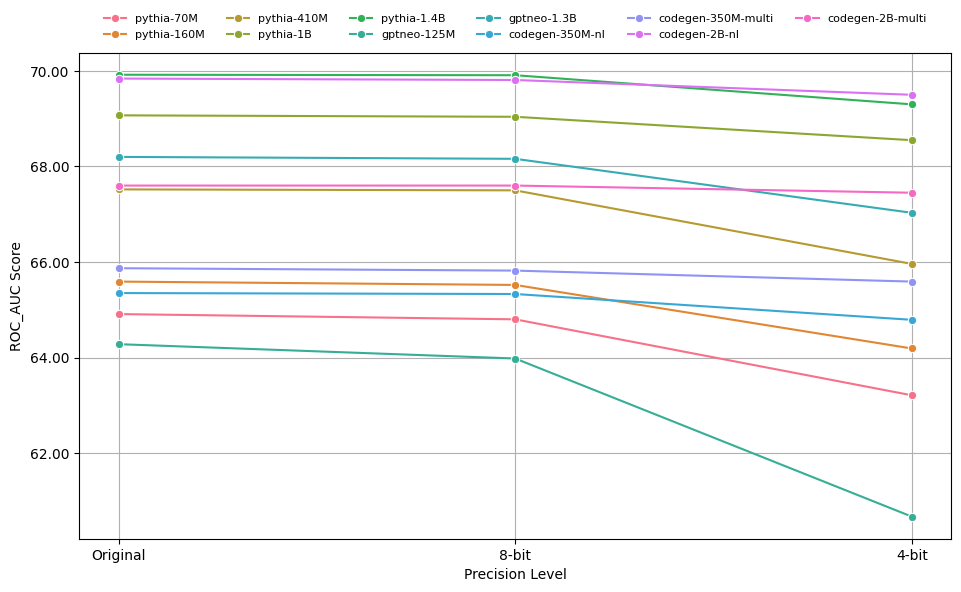

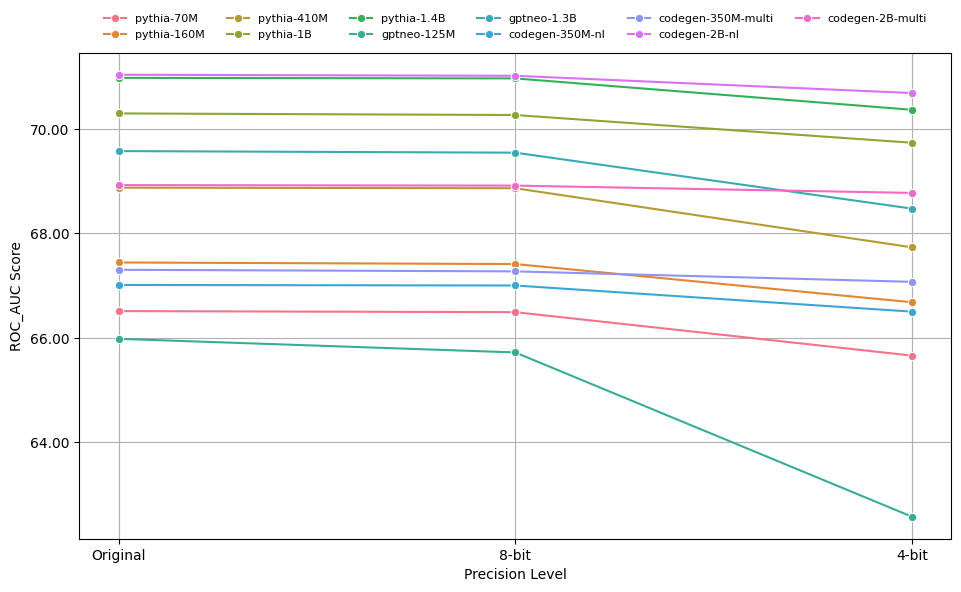

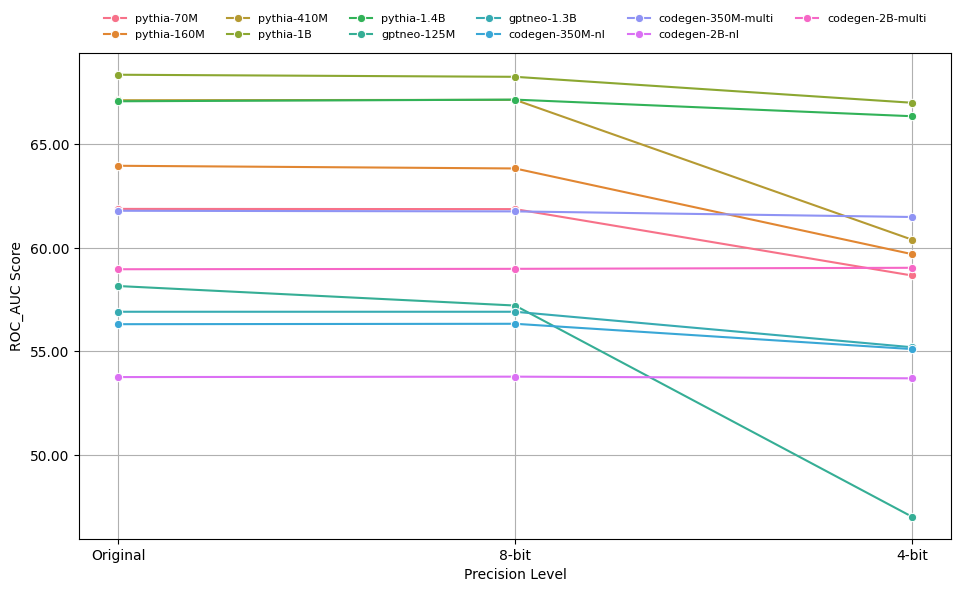

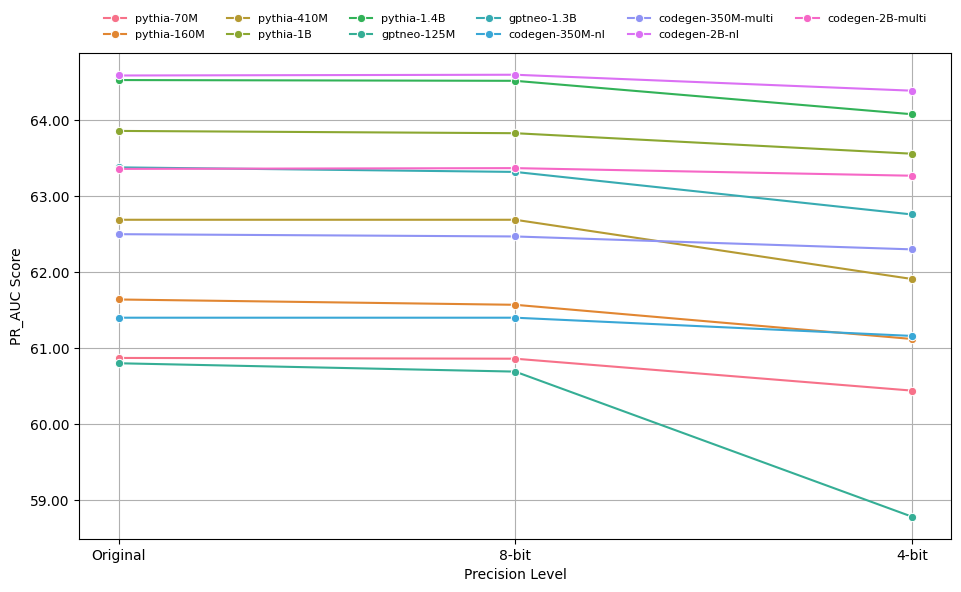

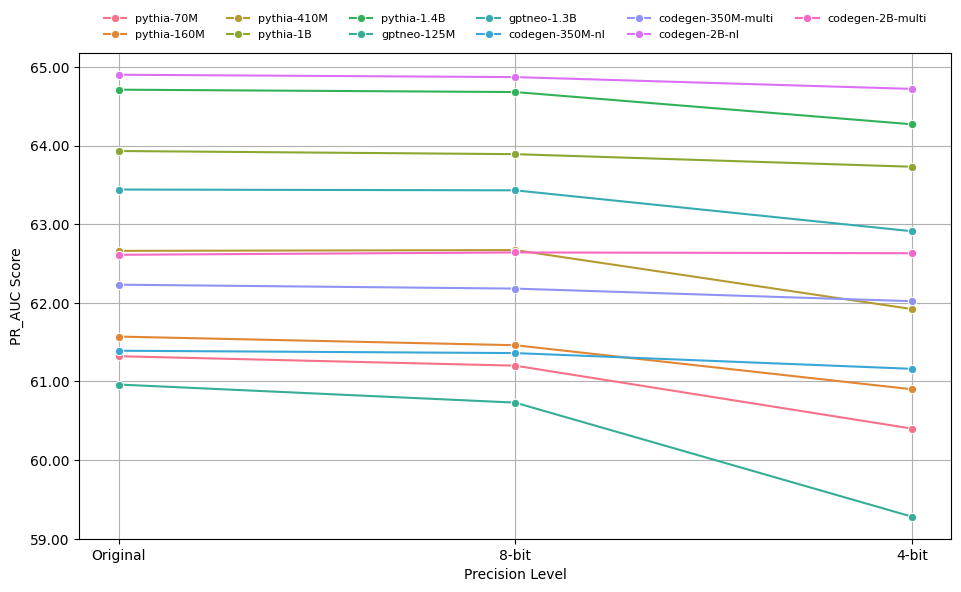

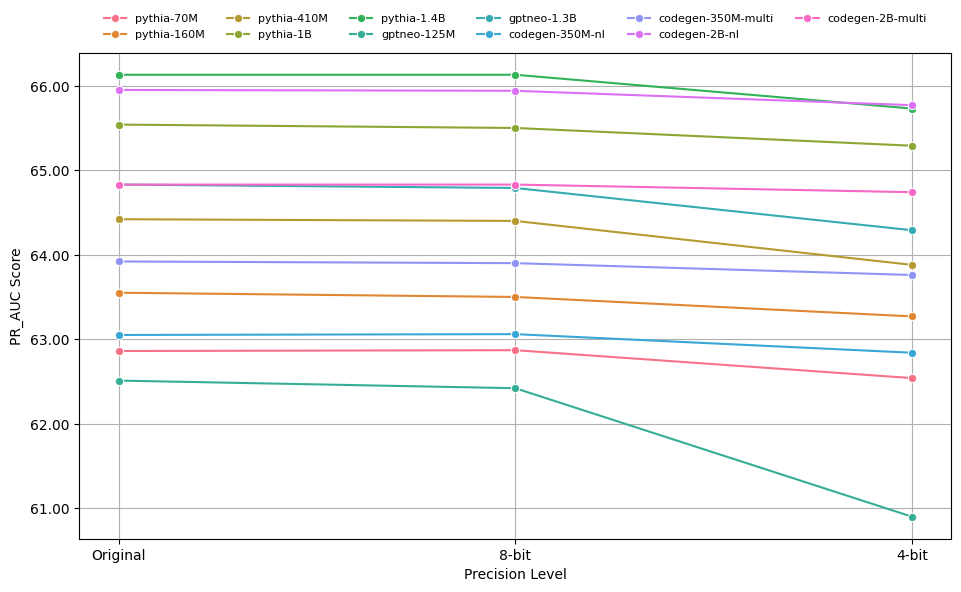

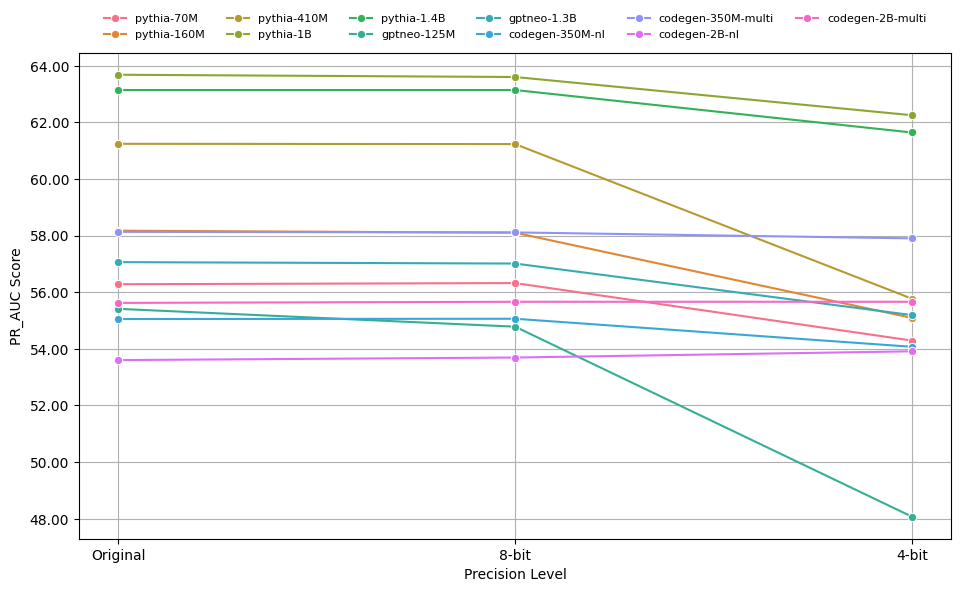

In [20]:
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC"])
graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-4.2.1.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.1"])
df = df.rename(columns={"ROC_AUC.1": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="MIN_K", fileName="RQ-4.2.2.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.2"])
df = df.rename(columns={"ROC_AUC.2": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="ZLIB", fileName="RQ-4.2.3.png")
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.3"])

df = df.rename(columns={"ROC_AUC.3": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="REF.", fileName="RQ-4.2.4.png")


metric = "PR_AUC"

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", metric])
graph_roc_auc(df, score_col=metric, miaName="LOSS", fileName="RQ-4.2.5.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "PR_AUC.1"])
df = df.rename(columns={"PR_AUC.1": metric})
graph_roc_auc(df, score_col=metric, miaName="MIN_K", fileName="RQ-4.2.6.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "PR_AUC.2"])
df = df.rename(columns={"PR_AUC.2": metric})
graph_roc_auc(df, score_col=metric, miaName="ZLIB", fileName="RQ-4.2.7.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "PR_AUC.3"])
df = df.rename(columns={"PR_AUC.3": metric})
graph_roc_auc(df, score_col=metric, miaName="REF.", fileName="RQ-4.2.8.png")

## RQ-3: Correlation between task performance and MIA

In [21]:
df = pd.read_csv(full_url, skiprows=2)
df

,Model,Compression,Size (MB),BLEU,ROC_AUC,PR_AUC,ROC_AUC.1,PR_AUC.1,ROC_AUC.2,PR_AUC.2,ROC_AUC.3,PR_AUC.3
0,pythia-70M,Original,281.73,42.00,64.55,60.87,64.91,61.32,66.51,62.86,61.87,56.28
1,pythia-70M,8-bit,122.13,41.39,64.53,60.86,64.80,61.20,66.49,62.87,61.86,56.32
2,pythia-70M,4-bit,113.77,39.21,63.36,60.44,63.21,60.40,65.66,62.54,58.66,54.29
3,pythia-160M,Original,649.34,42.49,65.70,61.64,65.59,61.57,67.44,63.55,63.95,58.17
4,pythia-160M,8-bit,240.12,42.31,65.66,61.57,65.52,61.46,67.41,63.50,63.82,58.10
5,pythia-160M,4-bit,202.65,40.60,64.50,61.12,64.19,60.90,66.68,63.27,59.69,55.09
6,pythia-410M,Original,1621.43,43.51,67.41,62.69,67.52,62.66,68.87,64.42,67.11,61.24
7,pythia-410M,8-bit,509.70,43.61,67.40,62.69,67.50,62.67,68.86,64.40,67.13,61.23
8,pythia-410M,4-bit,376.75,42.41,65.67,61.91,65.96,61.92,67.73,63.88,60.39,55.77
9,pythia-1B,Original,4047.19,44.18,68.99,63.86,69.07,63.93,70.29,65.54,68.34,63.68


In [28]:
def generate_graphs(taskPerformance, MIA_attack, MIA_score, i):
    model_order = ['pythia-70M', 'pythia-160M', 'pythia-410M', 'pythia-1B', 'pythia-1.4B', 'gptneo-125M', 'gptneo-1.3B', 'codegen-350M-nl', 'codegen-2B-nl', 'codegen-350M-multi', 'codegen-2B-multi']
    short_names = {
        'pythia-70M': 'P-70M',
        'pythia-160M': 'P-160M',
        'pythia-410M': 'P-410M',
        'pythia-1B': 'P-1B',
        'pythia-1.4B': 'P-1.4B',
        'gptneo-125M': 'G-125M',
        'gptneo-1.3B': 'G-1.3B',
        'codegen-350M-nl': 'C-350M-nl',
        'codegen-2B-nl': 'C-2B-nl',
        'codegen-350M-multi': 'C-350M-m',
        'codegen-2B-multi': 'C-2B-m'
    }
    colors = {
        'pythia-70M': 'red',
        'pythia-160M': 'purple',
        'pythia-410M': 'blue',
        'pythia-1B': 'orange',
        'pythia-1.4B': 'green',
        'gptneo-125M': 'pink',
        'gptneo-1.3B': 'brown',
        'codegen-350M-nl': 'yellow',
        'codegen-2B-nl': 'lime',
        'codegen-350M-multi': 'magenta',
        'codegen-2B-multi': 'cyan'
    }
    

    compression_order = ['Original', '8-bit', '4-bit']
    markers = {'Original': 'o', '8-bit': 's', '4-bit': '^'}
    serials = ['a)', 'b)', 'c)']
    

    # Create a 2x2 grid of subplots with adjusted width
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    
    # Add more space at the top for the legends
    plt.subplots_adjust(top=0.82)
    
    # Main title
    # fig.suptitle(f'Relationship between Task Performance and {MIA_attack} MIA ({MIA_score.split(".")[0]})', 
    #             fontsize=10, y=0.95)
    
    # Flatten the axes array for easier iteration
    axs = axes.flatten()
    
    # Create subgraphs for each compression type
    for idx, compression in enumerate(compression_order):
        ax = axs[idx]
        
        # Plot points for the current compression type
        for model in model_order:
            subset = df[(df['Model'] == model) & (df['Compression'] == compression)]
            if not subset.empty:
                ax.scatter(subset[taskPerformance], subset[MIA_score],
                          c=colors[model],
                          marker=markers[compression],
                          s=120,
                          alpha=0.8,
                          edgecolors='w',
                          linewidths=1)
        
        # Add regression line
        sns.regplot(x=taskPerformance, y=MIA_score, 
                    data=df[df['Compression'] == compression],
                    scatter=False, ci=95,
                    ax=ax,
                    line_kws={'color': 'black', 'alpha': 0.2, 'linestyle': '--'})
        
        # Calculate correlation for this compression
        corr = df[df['Compression'] == compression][taskPerformance].corr(
               df[df['Compression'] == compression][MIA_score])
        
        # Add correlation annotation
        x_pos = ax.get_xlim()[0] + 0.65 * (ax.get_xlim()[1] - ax.get_xlim()[0])
        y_pos = ax.get_ylim()[1] - 0.7 * (ax.get_ylim()[1] - ax.get_ylim()[0])
        
        ax.annotate(f'Pearson r = {corr:.3f}', 
                   xy=(x_pos, y_pos), xycoords='data',
                   fontsize=10, bbox=dict(boxstyle='round', alpha=0.2))
        
        ax.set_title(f'{serials[idx]} {compression}')
        ax.set_xlabel('Task Performance (CodeBLEU score)')
        ax.set_ylabel(f'MIA Score ({MIA_score.split(".")[0]})')
        ax.grid(True, alpha=0.3)
    
    # Create the fourth subgraph with all compression types
    ax = axs[3]
    for model in model_order:
        for compression in compression_order:
            subset = df[(df['Model'] == model) & (df['Compression'] == compression)]
            if not subset.empty:
                ax.scatter(subset[taskPerformance], subset[MIA_score],
                          c=colors[model],
                          marker=markers[compression],
                          s=120,
                          alpha=0.8,
                          edgecolors='w',
                          linewidths=1)
    
    # Add regression line for all data
    sns.regplot(x=taskPerformance, y=MIA_score, data=df,
                scatter=False, ci=95,
                ax=ax,
                line_kws={'color': 'black', 'alpha': 0.2, 'linestyle': '--'})
    
    # Calculate overall correlation
    corr = df[taskPerformance].corr(df[MIA_score])
    
    # Add correlation annotation
    x_pos = ax.get_xlim()[0] + 0.65 * (ax.get_xlim()[1] - ax.get_xlim()[0])
    y_pos = ax.get_ylim()[1] - 0.7 * (ax.get_ylim()[1] - ax.get_ylim()[0])
    
    ax.annotate(f'Pearson r = {corr:.3f}', 
               xy=(x_pos, y_pos), xycoords='data',
               fontsize=10, bbox=dict(boxstyle='round', alpha=0.2))
    
    ax.set_title('d) All Models and their Types')
    ax.set_xlabel('Task Performance (CodeBLEU score)')
    ax.set_ylabel(f'MIA Score ({MIA_score.split(".")[0]})')
    ax.grid(True, alpha=0.3)
    
    # Create legend elements
    model_legend_elements = [Line2D([0], [0], marker='o', color='w', label=short_names[model],
                            markerfacecolor=colors[model], markersize=8) 
                            for model in model_order]
    
    compression_legend_elements = [Line2D([0], [0], marker=markers[comp], color='w', label=comp,
                                  markerfacecolor='gray', markersize=8)
                                  for comp in compression_order]
    
    # Create two separate legends at the top
    # First legend for models (left side)
    legend1 = fig.legend(handles=model_legend_elements,
                       title='Models (P=Pythia, G=GPT-Neo, C=CodeGen)',
                       loc='upper left',
                       bbox_to_anchor=(0.05, 0.94),  # Left position
                       ncol=6,
                       fontsize=10,
                       title_fontsize=9,
                       framealpha=0.8)
    
    # Second legend for compression types (right side)
    legend2 = fig.legend(handles=compression_legend_elements,
                       title='Compression Types',
                       loc='upper right',
                       bbox_to_anchor=(.93, 0.92),  # Right position
                       ncol=3,
                       fontsize=10,
                       title_fontsize=9,
                       framealpha=0.8)
    
    # Adjust layout to make space for legends
    plt.tight_layout(rect=[0, 0, 1, 0.85])  # Adjust bottom space
    
    plt.savefig(f'./output/RQ4.3.{i}.png', dpi=300, bbox_inches='tight')
    plt.show()

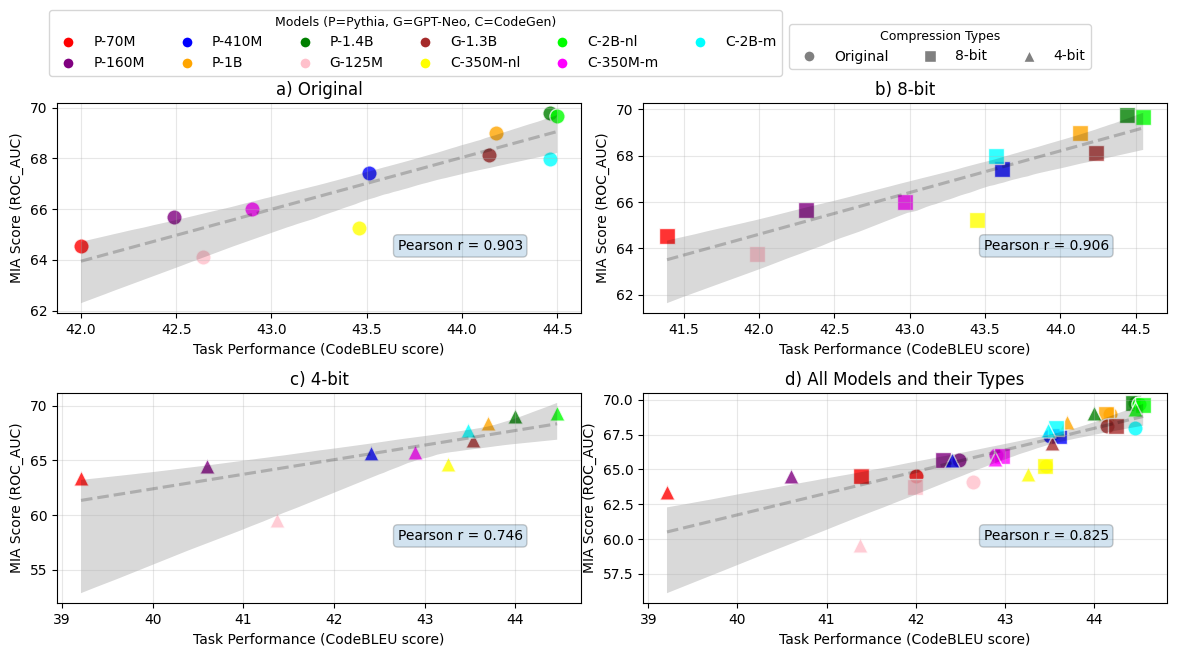

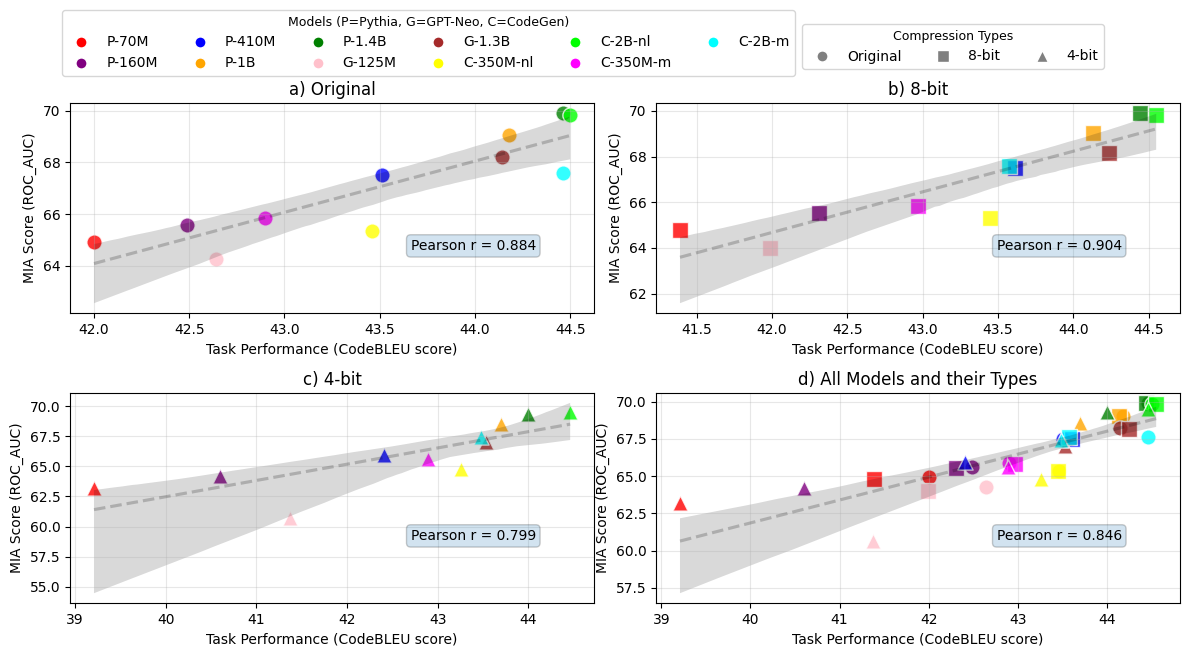

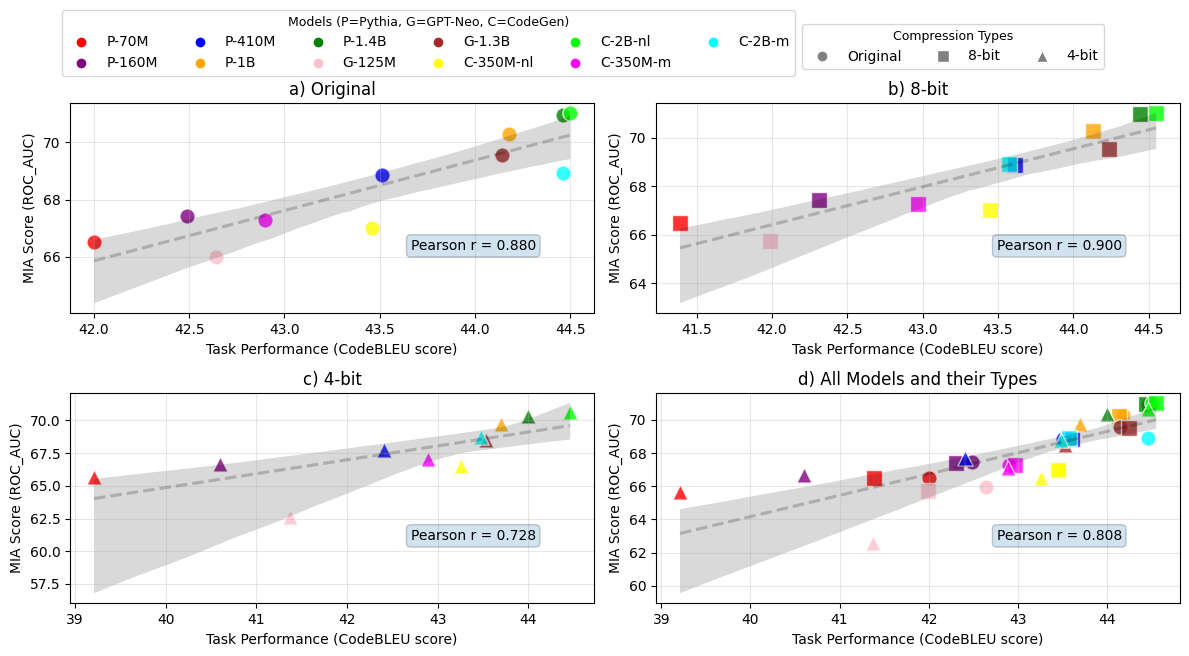

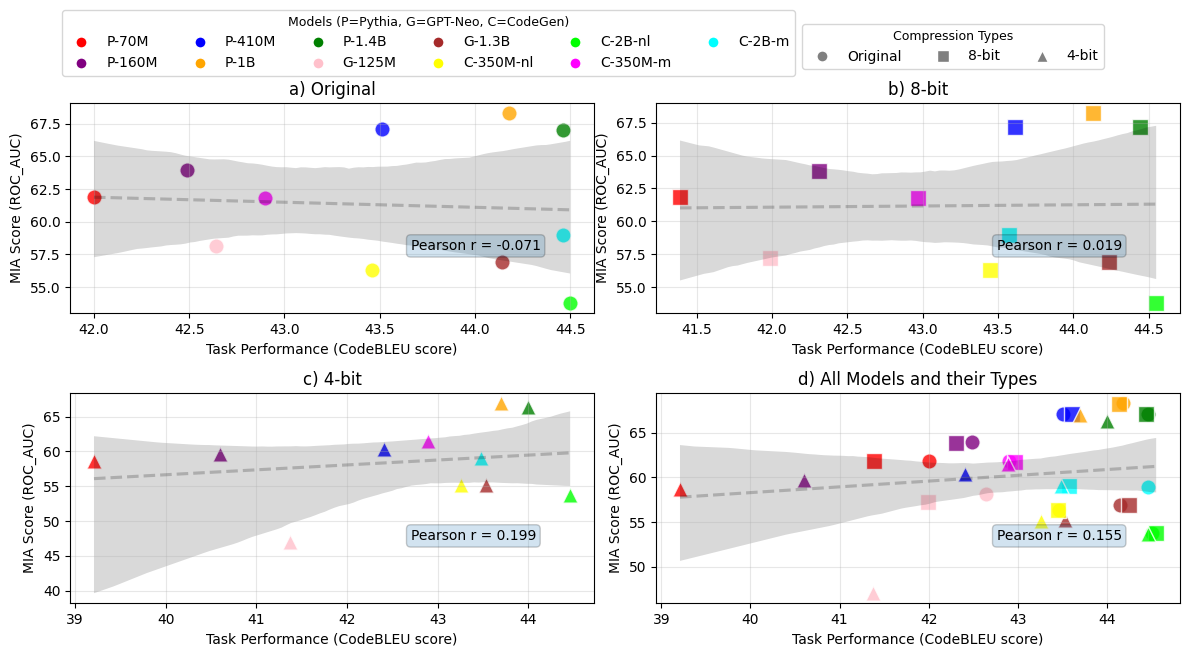

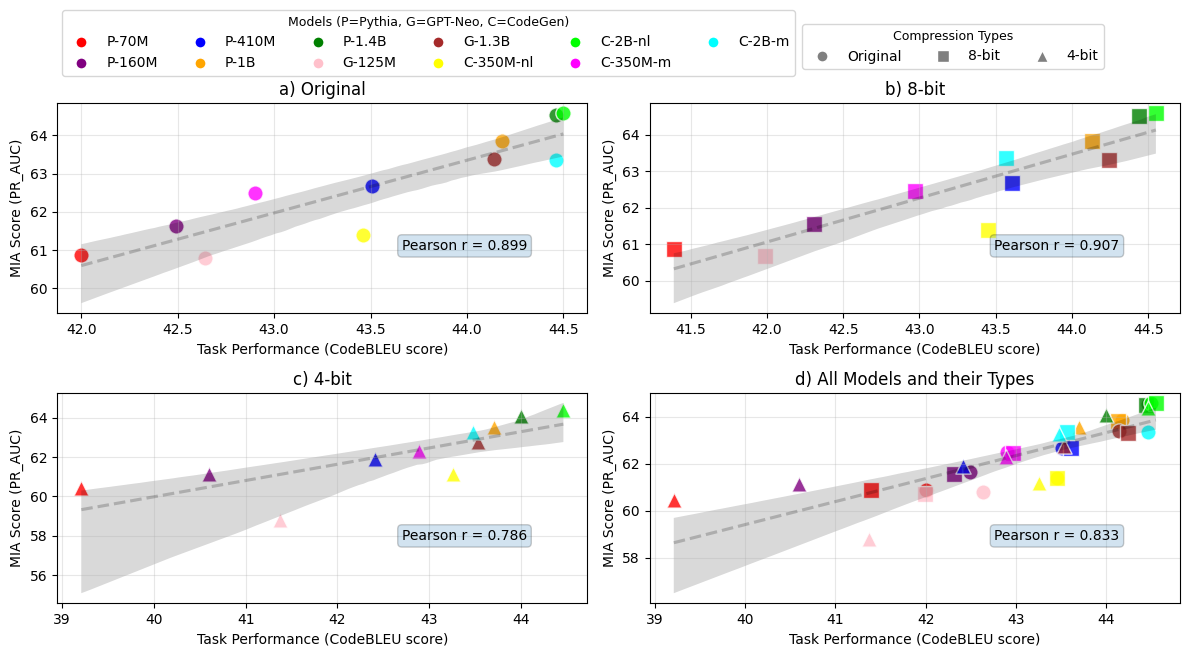

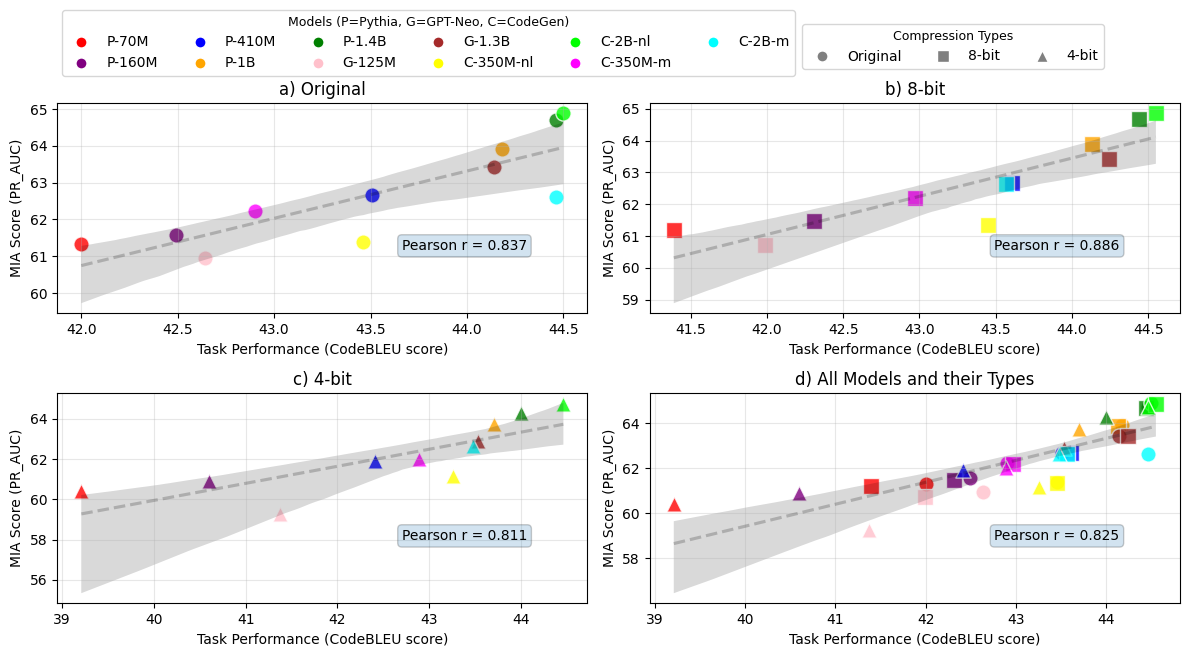

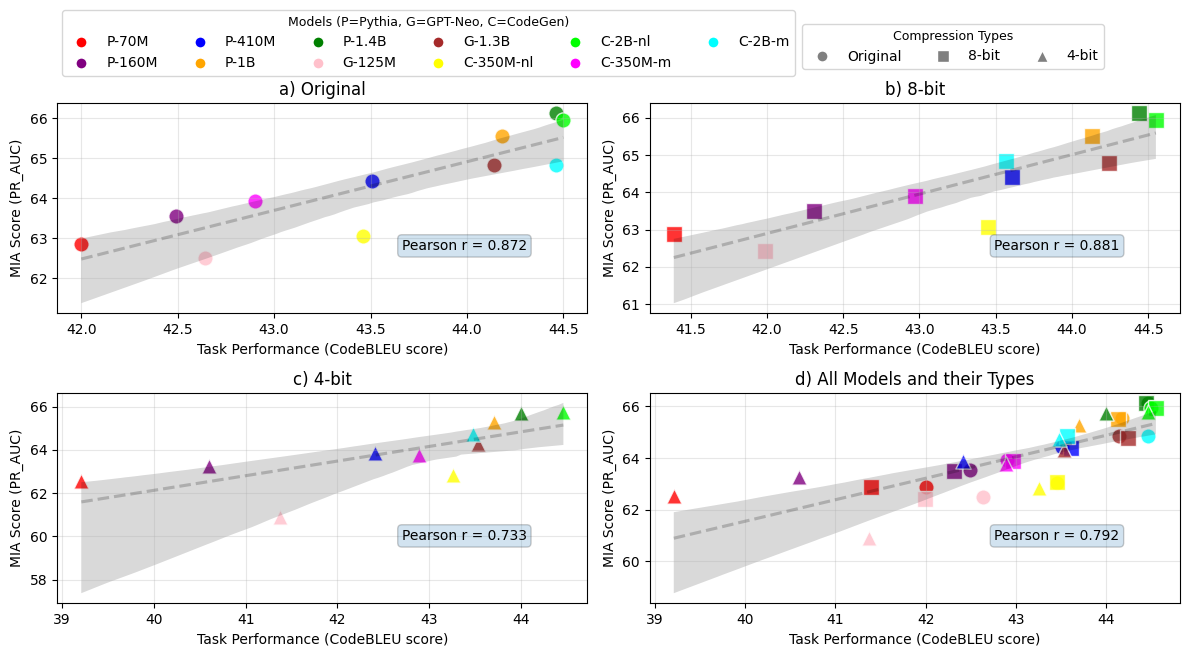

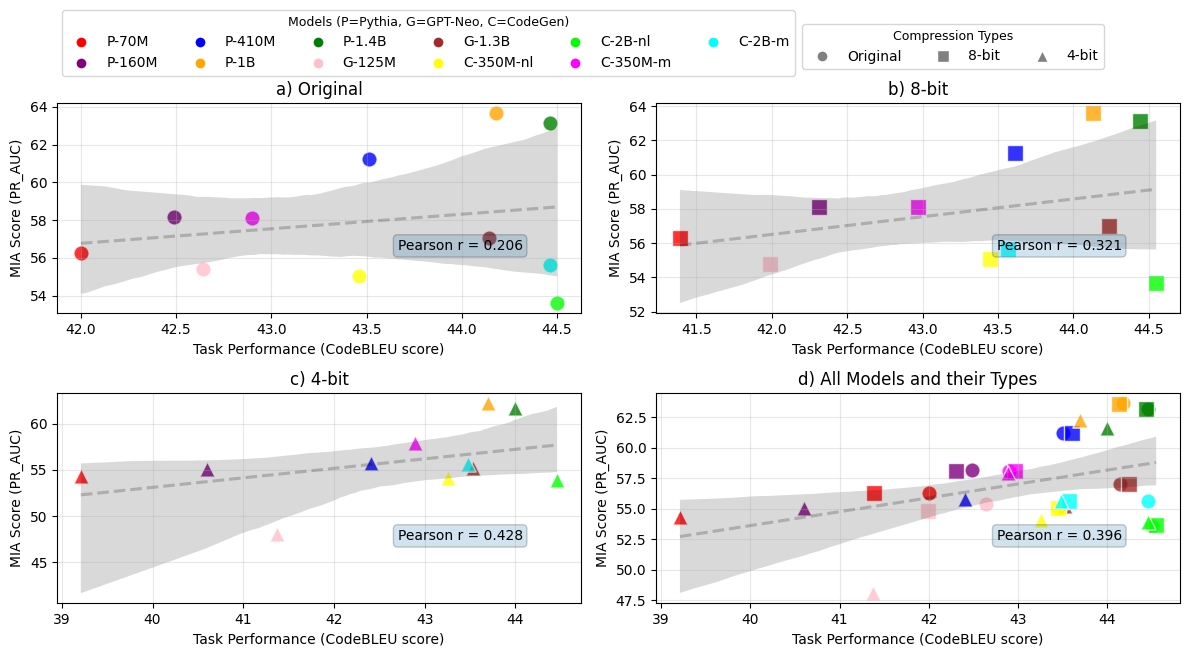

In [29]:
taskPerformance = "BLEU"
MIA_attacks = ["LOSS", "MIN_K", "ZLIB", "REF"]
MIA_scores = ["ROC_AUC", "ROC_AUC.1", "ROC_AUC.2", "ROC_AUC.3"]
for i, (MIA_attack, MIA_score) in enumerate(zip(MIA_attacks, MIA_scores), start=1):
    generate_graphs(taskPerformance, MIA_attack, MIA_score, i)


MIA_scores = ["PR_AUC", "PR_AUC.1", "PR_AUC.2", "PR_AUC.3"]
for i, (MIA_attack, MIA_score) in enumerate(zip(MIA_attacks, MIA_scores), start=5):
    generate_graphs(taskPerformance, MIA_attack, MIA_score, i)